ARAVINDAN D

212223240012

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
DATA_DIR = Path(
    r"C:\Users\admin\Downloads\Cat-Dog_Pandas-20260603T040637Z-3-001\Cat-Dog_Pandas"
)

train_path = DATA_DIR / "Train"

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

In [4]:
dataset = datasets.ImageFolder(train_path, transform=train_transform)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Classes: ['cat', 'dog', 'panda']
Total Images: 2100


In [5]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

In [6]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

In [7]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(128*16*16, 256)
        self.fc2 = nn.Linear(256, 3)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

model = CNN()

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

In [9]:
epochs = 10

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/10] Loss: 0.9029
Epoch [2/10] Loss: 0.7953
Epoch [3/10] Loss: 0.7535
Epoch [4/10] Loss: 0.6801
Epoch [5/10] Loss: 0.6778
Epoch [6/10] Loss: 0.6301
Epoch [7/10] Loss: 0.5895
Epoch [8/10] Loss: 0.5574
Epoch [9/10] Loss: 0.5203
Epoch [10/10] Loss: 0.5154


In [10]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 70.48%


In [11]:
torch.save(model.state_dict(), "animal_classifier.pth")
print("Model saved successfully!")

Model saved successfully!


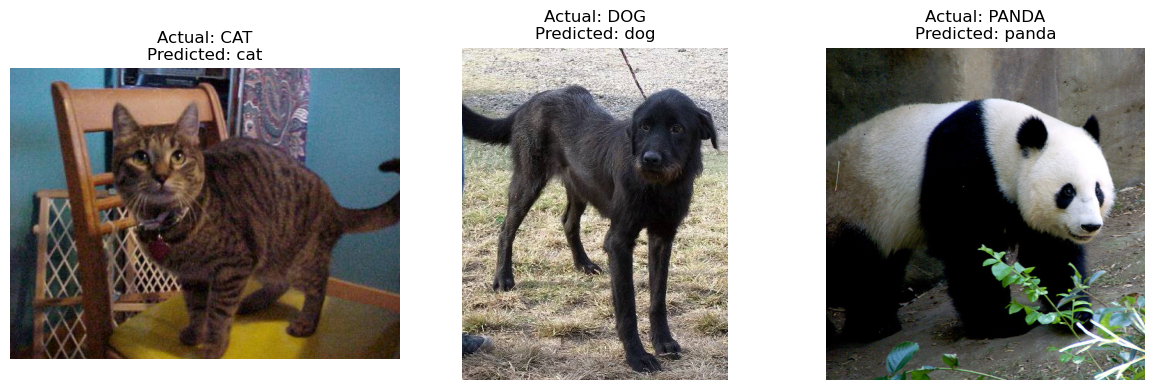

In [15]:
from PIL import Image
import matplotlib.pyplot as plt
import torch

classes = ["CAT", "DOG", "PANDA"]

plt.figure(figsize=(12,4))

for i, cls in enumerate(classes):

    # First image from each class
    img_path = list((train_path / cls).glob("*"))[0]

    img = Image.open(img_path).convert("RGB")

    # Prediction
    img_tensor = train_transform(img).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        _, pred = torch.max(output, 1)

    predicted_class = dataset.classes[pred.item()]

    # Display
    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(
        f"Actual: {cls}\nPredicted: {predicted_class}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()